In [331]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

#Data loading by use yfinance

df = yf.download("AAPL",start="2015-01-01")
df



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214890,24.682222,23.776350,24.671147,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781889,24.839475,24.075353,24.192741,237458000
...,...,...,...,...,...
2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300
2026-02-26,272.950012,276.109985,270.799988,274.950012,32345100


In [332]:
# To see the index multindex 
print(df.columns)


MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [335]:
# After checking i got that there is multindex problem so to solve it i used next step
#Here index  level 0 was prices andLevel 1 was tacker which was so 
# To remove the multidex the tracker-
df.columns=df.columns.droplevel(1)
#which is same as 
#df.columns=df.columns.get_values(0)


In [337]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [339]:
#To get general information about the data-
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2807 entries, 2015-01-02 to 2026-03-03
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2807 non-null   float64
 1   High    2807 non-null   float64
 2   Low     2807 non-null   float64
 3   Open    2807 non-null   float64
 4   Volume  2807 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 131.6 KB


In [341]:
#For sorting the data index wise (date)
df = df.sort_index()
print(df)

Price            Close        High         Low        Open     Volume
Date                                                                 
2015-01-02   24.214890   24.682222   23.776350   24.671147  212818400
2015-01-05   23.532719   24.064282   23.346673   23.984547  257142000
2015-01-06   23.534935   23.794071   23.173914   23.596950  263188400
2015-01-07   23.864946   23.964614   23.632387   23.743129  160423600
2015-01-08   24.781889   24.839475   24.075353   24.192741  237458000
...                ...         ...         ...         ...        ...
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900
2026-03-03  263.750000  265.559998  260.130005  263.480011   37994695

[2807 rows x 5 columns]


In [343]:
#To check data availability-
print(df.index.min())
print(df.index.max())

2015-01-02 00:00:00
2026-03-03 00:00:00


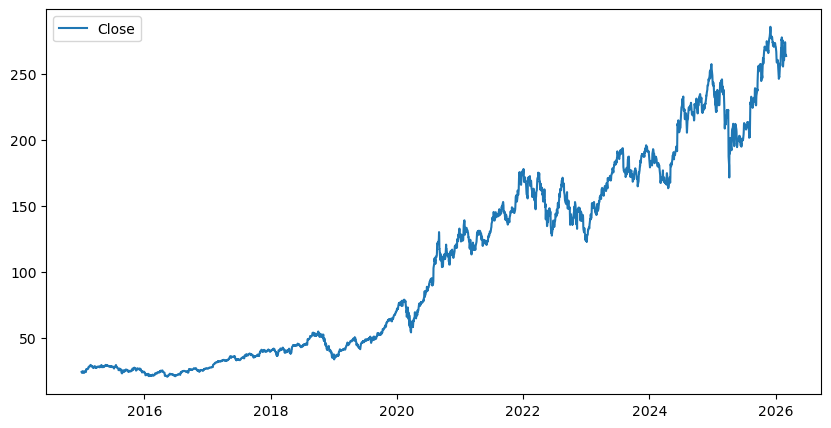

In [346]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.Close, label="Close")
plt.legend()
plt.show()

In [348]:
#To check whether missing values exist or not-
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

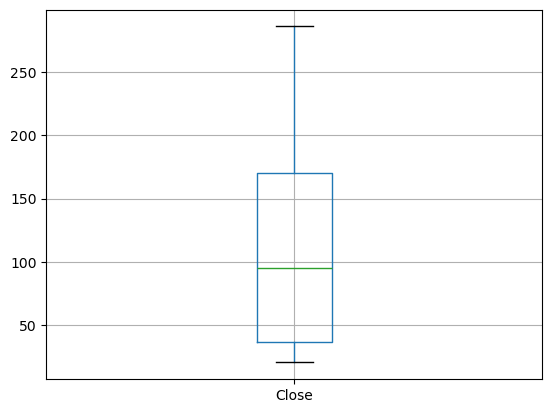

In [350]:
# To see the outliers in data but usually in case of time series data we do not remove the outliers cause they are dependent
df[['Close']].boxplot()
plt.show()

In [352]:
# To calculate daily return means we calculate the % difference between close price of today and yesterday's as data for the training model 
#which will help to understand the trend,So we create new column in data set named as return as values as % change in daily close prices.
df['Return'] = df['Close'].pct_change()
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-02   24.214890   24.682222   23.776350   24.671147  212818400   
2015-01-05   23.532719   24.064282   23.346673   23.984547  257142000   
2015-01-06   23.534935   23.794071   23.173914   23.596950  263188400   
2015-01-07   23.864946   23.964614   23.632387   23.743129  160423600   
2015-01-08   24.781889   24.839475   24.075353   24.192741  237458000   
...                ...         ...         ...         ...        ...   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   
2026-03-03  263.750000  265.559998  260.130005  263.480011   37994695   

Price         Return  
Date                  
2015

In [354]:
#Whatever we are doing now it is for our model training such that 
#our model can fit correctone model on training dataset and try to give  most correct one prediction
#Now we are calculating Moving Averages (5 and 10, And always remember for rolling means window from 5-1)

df['MA_5'] = df['Close'].rolling(5).mean().shift(1)
df['MA_10'] = df['Close'].rolling(10).mean().shift(1)
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-02   24.214890   24.682222   23.776350   24.671147  212818400   
2015-01-05   23.532719   24.064282   23.346673   23.984547  257142000   
2015-01-06   23.534935   23.794071   23.173914   23.596950  263188400   
2015-01-07   23.864946   23.964614   23.632387   23.743129  160423600   
2015-01-08   24.781889   24.839475   24.075353   24.192741  237458000   
...                ...         ...         ...         ...        ...   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   
2026-03-03  263.750000  265.559998  260.130005  263.480011   37994695   

Price         Return        MA_5       MA_10  
Dat

In [356]:
#Just for clarification that i doubted that there is nay problem regarding the MA5 and MA10 cause they are in next row so for confirmation i do this
# But after performing this i got to know everything is normal 
# We are doing feature engineering for good model training to get correct trend for ML
print(df.columns)
print(df.columns.nlevels)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA_5', 'MA_10'], dtype='object', name='Price')
1


In [358]:
# Here all the rows which were including NaN values bcause of calcculation of MA5 and MA10 
# so in short we delete or remove the first 9 rows cause ML do not work with NaN values gives Error - data cleaning
df= df.dropna()
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-16   23.475132   23.827293   23.300159   23.705476  314053200   
2015-01-20   24.079784   24.135155   23.588089   23.884877  199599600   
2015-01-21   24.263618   24.598059   23.980117   24.130726  194303600   
2015-01-22   24.894848   24.910352   24.301270   24.420871  215185600   
2015-01-23   25.023314   25.193856   24.702160   24.872704  185859200   
...                ...         ...         ...         ...        ...   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   
2026-03-03  263.750000  265.559998  260.130005  263.480011   37994695   

Price         Return        MA_5       MA_10  
Dat

In [360]:
#Now for creating "target" variable 
#  In target variable we have data closing price of tommorrow is todays target price
# In this type the of new column will form
# From onword this we are calculating for regression method and i will do notify when we start for the Classification method

print(df.columns)
df["Target"] = df["Close"].shift(-1)
print(df)

# For understanding ()  -  function call ( Code run hoil)
#                   []  - column  selection (selection)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA_5', 'MA_10'], dtype='object', name='Price')
Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-16   23.475132   23.827293   23.300159   23.705476  314053200   
2015-01-20   24.079784   24.135155   23.588089   23.884877  199599600   
2015-01-21   24.263618   24.598059   23.980117   24.130726  194303600   
2015-01-22   24.894848   24.910352   24.301270   24.420871  215185600   
2015-01-23   25.023314   25.193856   24.702160   24.872704  185859200   
...                ...         ...         ...         ...        ...   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   
2026-03-03  263.7

In [362]:
print(df.columns)


Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'MA_5', 'MA_10',
       'Target'],
      dtype='object', name='Price')


In [364]:
df[["Return","Target"]].corr()

Price,Return,Target
Price,,
Return,1.000000,0.006507
Target,0.006507,1.000000


In [366]:
df['Return_lag1'] = df['Return'].shift(1)
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-16   23.475132   23.827293   23.300159   23.705476  314053200   
2015-01-20   24.079784   24.135155   23.588089   23.884877  199599600   
2015-01-21   24.263618   24.598059   23.980117   24.130726  194303600   
2015-01-22   24.894848   24.910352   24.301270   24.420871  215185600   
2015-01-23   25.023314   25.193856   24.702160   24.872704  185859200   
...                ...         ...         ...         ...        ...   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   
2026-03-03  263.750000  265.559998  260.130005  263.480011   37994695   

Price         Return        MA_5       MA_10      

In [368]:
df= df.dropna()
print(df)

Price            Close        High         Low        Open     Volume  \
Date                                                                    
2015-01-20   24.079784   24.135155   23.588089   23.884877  199599600   
2015-01-21   24.263618   24.598059   23.980117   24.130726  194303600   
2015-01-22   24.894848   24.910352   24.301270   24.420871  215185600   
2015-01-23   25.023314   25.193856   24.702160   24.872704  185859200   
2015-01-26   25.049883   25.328954   24.983439   25.191633  222460000   
...                ...         ...         ...         ...        ...   
2026-02-24  272.140015  274.890015  267.709991  267.859985   47014600   
2026-02-25  274.230011  274.940002  271.049988  271.779999   33714300   
2026-02-26  272.950012  276.109985  270.799988  274.950012   32345100   
2026-02-27  264.179993  272.809998  262.890015  272.809998   72366500   
2026-03-02  264.720001  266.529999  260.200012  262.410004   41827900   

Price         Return        MA_5       MA_10      

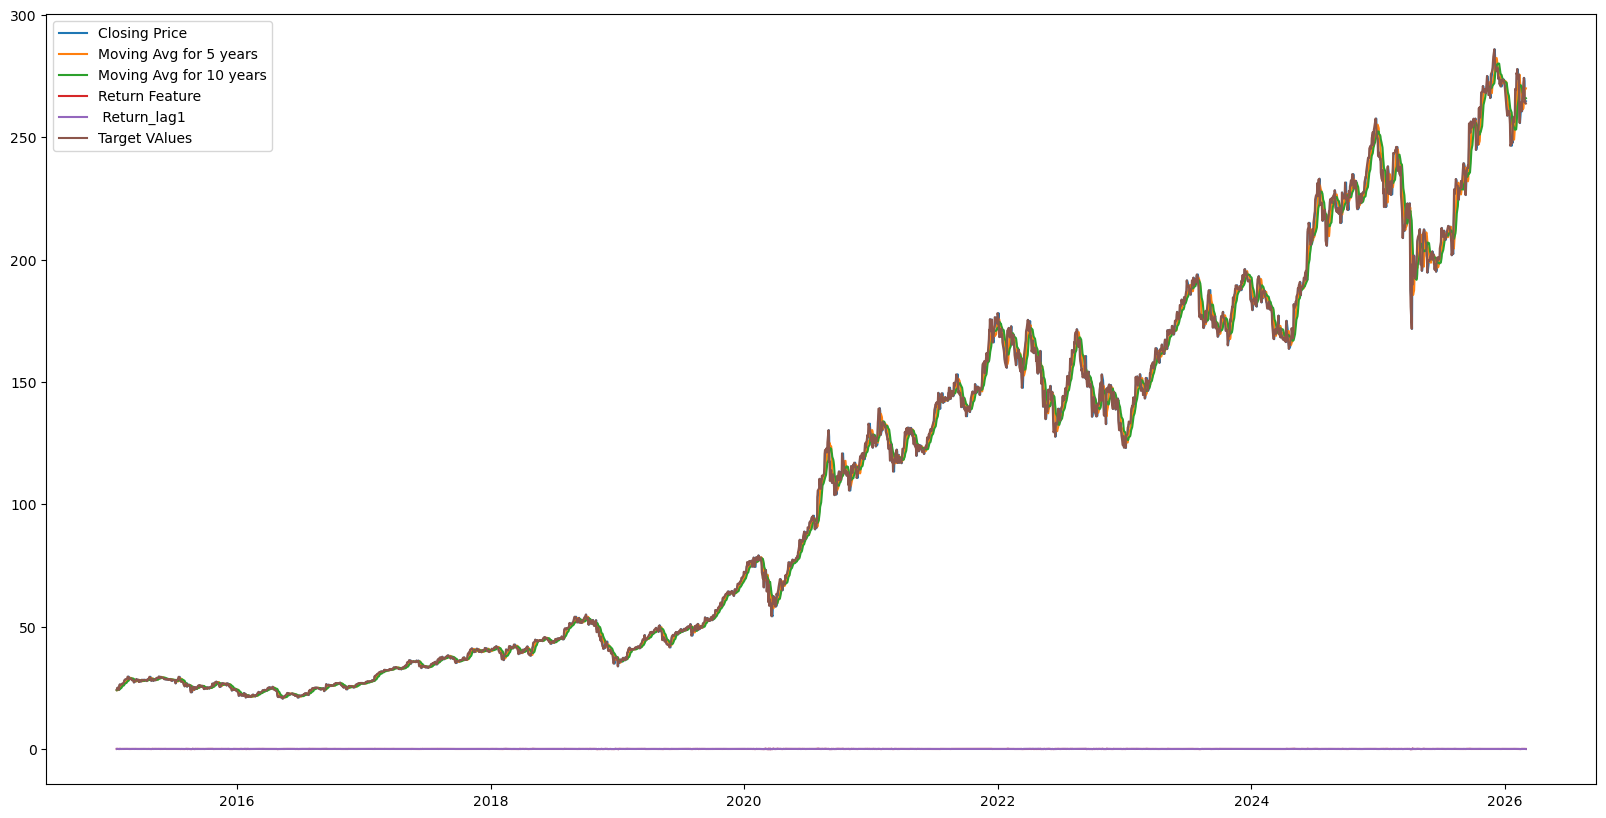

In [371]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plt.plot(df.Close, label="Closing Price")
plt.plot(df.MA_5, label="Moving Avg for 5 years")
plt.plot(df.MA_10, label="Moving Avg for 10 years")
plt.plot(df.Return, label="Return Feature")
plt.plot(df.Return_lag1, label=" Return_lag1")
plt.plot(df.Target, label="Target VAlues")
plt.legend()
plt.show()

In [373]:
df[['Return_lag1', 'Target']].corr()

Price,Return_lag1,Target
Price,,
Return_lag1,1.000000,0.006866
Target,0.006866,1.000000


In [375]:
#creating training set for model of ML
#Here features is the data for training of model and we have variable X as independent variable
features = ['MA_5', 'MA_10', 'Return','Return_lag1']
X = df[features]
y = df['Target']


In [377]:
# here we are performing the spliting of data for the trainig and testing
# here we used 80% data for training and 20% for testing
# [:split]==(0:80)
# [split:]==(80:100)

split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


In [379]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

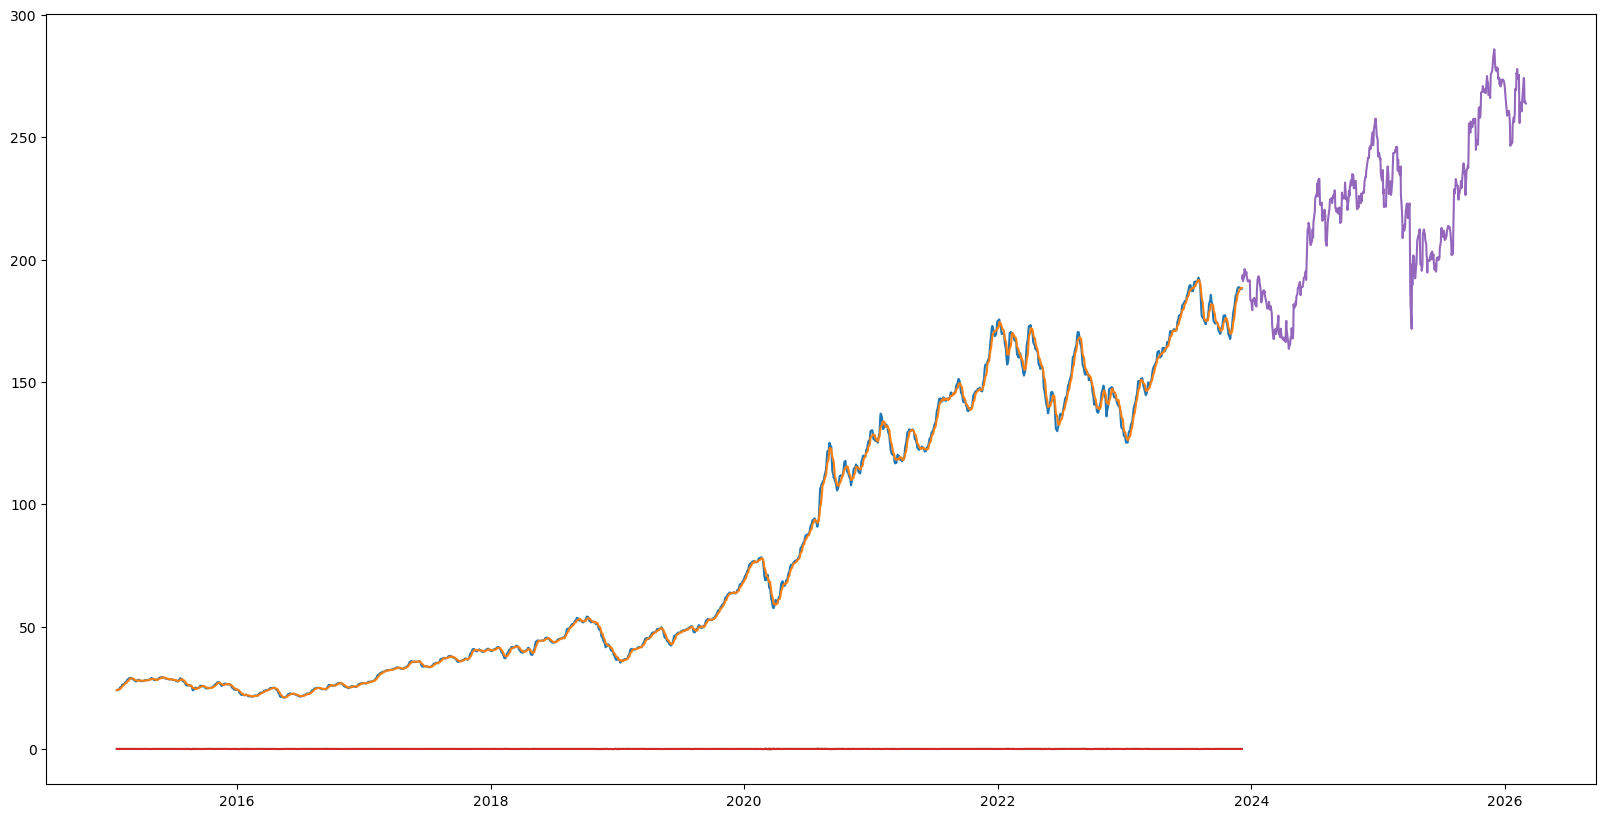

In [381]:
plt.figure(figsize=(20,10))


plt.plot(X_train, label="Train Data")
plt.plot(y_test, label="Test Data")


In [384]:
predictions = model.predict(X_test)


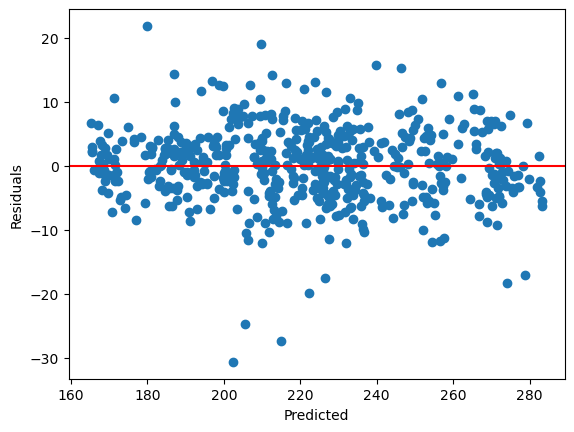

In [387]:
residuals = y_test - predictions

import matplotlib.pyplot as plt

plt.scatter(predictions, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

In [389]:
from sklearn.metrics import mean_absolute_error, r2_score ,root_mean_squared_error,mean_absolute_percentage_error,explained_variance_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
evs = explained_variance_score(y_test, predictions)


print("MAE:", mae)
print("R2 Score:", r2)
print("RMSE:",rmse)
print("MAPE:",mape) 
print("EVS:",evs)

MAE: 4.323045041770895
R2 Score: 0.9637479634472849
RMSE: 5.7845052402819075
MAPE: 0.019728193494985637
EVS: 0.9637602618942813


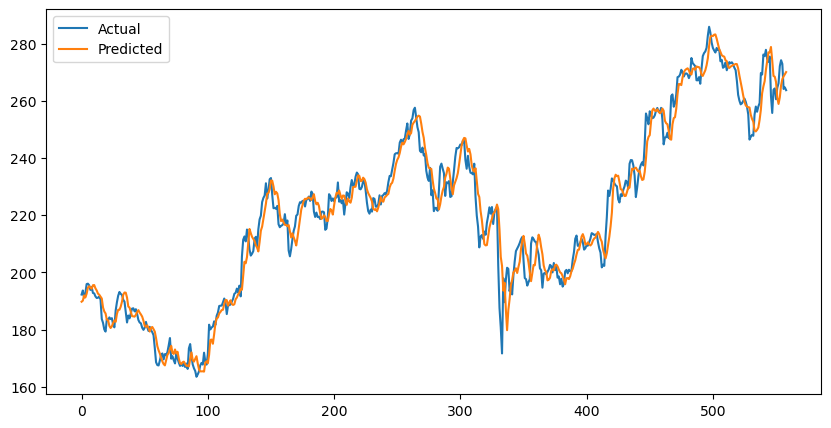

In [391]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()